# Per‑region Benth OU + Neural Networks (Model 1: NN calibration)

Your CSV has **many regions** (multiple rows per date). This notebook trains **one independent model per region**:

- Fit seasonal mean $s_r(t)$ (harmonic regression) for each region $r$
- Residuals $X_{r,t}=T_{r,t}-s_r(t)$
- Train a neural network that predicts $(\kappa_{r,t},\sigma_{r,t})$ from a rolling window and DOY features

Outputs per region:
- training / test NLL curves
- learned $\kappa_{r,t}$ and $\sigma_{r,t}$ over time
- standardized residual diagnostics
- optional Monte‑Carlo simulation + HDD example

**Note:** This is the "Model 1" approach (NN calibrates OU parameters).

In [8]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Load your CSV

Expected columns:
- `date`
- `region_code`
- `temp`

If your column names differ, rename them below.

In [9]:
CSV_PATH = "../EDA/region_avg.csv"  # <- change if needed
DATE_COL = "date"
REGION_COL = "region_code"
TEMP_COL = "daily_avg_temperature"

df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw.rename(columns={DATE_COL:"date", REGION_COL:"region_code", TEMP_COL:"daily_avg_temperature"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["temp"] = pd.to_numeric(df_raw["daily_avg_temperature"], errors="coerce")
df_raw["region_code"] = pd.to_numeric(df_raw["region_code"], errors="coerce")

df_raw = df_raw.dropna(subset=["date","temp","region_code"]).copy()
df_raw["region_code"] = df_raw["region_code"].astype(int)

print(df_raw.head())
print(df_raw.tail())
print("shape:", df_raw.shape)
print("regions:", df_raw["region_code"].nunique())


        date  region_code  daily_avg_temperature  temp
0 1970-01-01           11                  -2.40 -2.40
1 1970-01-01           24                  -2.50 -2.50
2 1970-01-01           28                   4.40  4.40
3 1970-01-01           44                  -3.35 -3.35
4 1970-01-01           52                  -0.85 -0.85
             date  region_code  daily_avg_temperature      temp
158009 2024-12-31           28               5.875000  5.875000
158010 2024-12-31           32               4.795455  4.795455
158011 2024-12-31           44              -0.102632 -0.102632
158012 2024-12-31           52               5.662500  5.662500
158013 2024-12-31           53               8.276667  8.276667
shape: (151743, 4)
regions: 8


## 2) Helper functions

In [10]:
def design_matrix_seasonality(dates: pd.Series, K: int = 3, include_trend: bool = True) -> np.ndarray:
    n = len(dates)
    doy = dates.dt.dayofyear.values.astype(float)
    parts = [np.ones(n)]
    if include_trend:
        t = np.arange(n) / 365.0
        parts.append(t)
    for k in range(1, K+1):
        parts.append(np.sin(2*np.pi*k*doy/365.0))
        parts.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(parts)

def fit_seasonal_mean(dates: pd.Series, temp: np.ndarray, K: int = 3):
    X = design_matrix_seasonality(dates, K=K, include_trend=True)
    y = temp.astype(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    s_hat = X @ beta
    return s_hat, beta

def doy_features(dates: pd.Series, harmonics: int = 3) -> np.ndarray:
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics+1):
        feats.append(np.sin(2*np.pi*k*doy/365.0))
        feats.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(feats)

def make_windows(x: np.ndarray, doy_feat: np.ndarray, window: int = 30):
    x = np.asarray(x, dtype=np.float32)
    doy_feat = np.asarray(doy_feat, dtype=np.float32)
    N, F = doy_feat.shape
    xs, xt, y, idx = [], [], [], []
    for t in range(window, N-1):
        inp = np.concatenate([x[t-window:t], doy_feat[t]], axis=0)
        xs.append(inp)
        xt.append(x[t])
        y.append(x[t+1])
        idx.append(t)
    return np.stack(xs), np.array(xt), np.array(y), np.array(idx)

class CalibNet(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, kappa_max: float = 0.5):
        super().__init__()
        self.kappa_max = kappa_max
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),  # raw_kappa, raw_sigma
        )
        self.softplus = nn.Softplus()

    def forward(self, x):
        raw = self.net(x)
        kappa = self.kappa_max * torch.sigmoid(raw[:, 0]) + 1e-6
        sigma = self.softplus(raw[:, 1]) + 1e-6
        return kappa, sigma

def ou_nll_euler(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)  # prevents log(0)/div0
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


In [11]:
# Model / data hyperparameters
K_HARMONICS = 3
DOY_HARMONICS = 3
WINDOW = 30
DT = 1.0
EPOCHS = 800
LR = 1e-3
HIDDEN = 64
KAPPA_MAX = 0.5

# All available regions
regions = sorted(df_raw["region_code"].dropna().astype(int).unique().tolist())
GRID_REGIONS = regions              # all regions

print("All regions:", regions)
print("Grid-search regions:", GRID_REGIONS)

All regions: [11, 24, 27, 28, 32, 44, 52, 53]
Grid-search regions: [11, 24, 27, 28, 32, 44, 52, 53]


## 3) Per‑region training configuration

This notebook now runs a **clean Model A-only workflow**:

1. build per-region baseline artifacts for grid search
2. run grid search over NN architectures
3. train the final region-specific Model A
4. inspect final diagnostics
5. export per-region `.pkl` files

Legacy Model B / Model C comparison cells were removed.

In [12]:
# ============================================================
# GRID SEARCH FOR NN ARCHITECTURE
# Uses the ORIGINAL Gaussian-trained Model A structure
# with your fixed date split
# ============================================================

import copy
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ---- search space ----
GRID_HIDDEN = [32, 64, 128]
GRID_ACTIVATION = ["tanh", "relu", "leakyrelu"]
GRID_N_LAYERS = [1, 2]

# ---- training / search settings ----
GRID_EPOCHS = 800
GRID_LR = 1e-3
GRID_KAPPA_MAX = 0.5
GRID_WEIGHT_DECAY = 1e-4
GRID_GRAD_CLIP = 1.0

# ---- early stopping settings ----
GRID_EARLY_STOPPING = True
GRID_EVAL_EVERY = 5
GRID_EARLY_STOP_PATIENCE = 12
GRID_EARLY_STOP_MIN_DELTA = 1e-5

train_end_date = pd.Timestamp("2013-12-31")
val_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")


def get_activation(name: str):
    name = name.lower()
    if name == "tanh":
        return nn.Tanh()
    elif name == "relu":
        return nn.ReLU()
    elif name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.01)
    else:
        raise ValueError(f"Unknown activation: {name}")


class CalibNetFlexible(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, activation: str = "tanh",
                 n_layers: int = 2, kappa_max: float = 0.5):
        super().__init__()
        self.kappa_max = kappa_max
        self.softplus = nn.Softplus()

        act = get_activation(activation)

        layers = []
        prev_dim = in_dim

        for _ in range(n_layers):
            layers.append(nn.Linear(prev_dim, hidden))
            layers.append(copy.deepcopy(act))
            prev_dim = hidden

        layers.append(nn.Linear(prev_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        raw = self.net(x)
        raw_kappa = raw[:, 0]
        raw_sigma = raw[:, 1]

        kappa = self.kappa_max * torch.sigmoid(raw_kappa) + 1e-6
        sigma = self.softplus(raw_sigma) + 1e-6
        return kappa, sigma


def ou_nll_OU_safe(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    kappa = torch.clamp(kappa, min=1e-6)
    sigma = torch.clamp(sigma, min=1e-6)

    exp_term = torch.exp(-kappa * dt)
    mean = x_t * exp_term
    var = (sigma ** 2) * (1.0 - torch.exp(-2.0 * kappa * dt)) / (2.0 * kappa)

    var = torch.clamp(var, min=1e-6)
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)

    return 0.5 * (torch.log(var) + resid2 / var).mean()


def compute_skewness(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 3)


def compute_kurtosis(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 4)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = 1.0 - ss_res / ss_tot

    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "corr": float(corr),
    }


def interval_metrics(y_true, mean_pred, sigma_pred, alpha=0.10):
    zcrit = 1.6448536269514722  # 90% central interval
    lower = mean_pred - zcrit * sigma_pred
    upper = mean_pred + zcrit * sigma_pred

    covered = ((y_true >= lower) & (y_true <= upper)).astype(float)
    picp = np.mean(covered)
    mpiw = np.mean(upper - lower)

    return {
        "picp_90": float(picp),
        "mpiw_90": float(mpiw),
    }

In [ ]:

# ============================================================
# BUILD BASE REGION ARTIFACTS + TRAIN/EVALUATE ONE GRID CONFIG
# ============================================================

results = []
models = {}
region_artifacts = {}

# Build common per-region inputs used by grid search
for r in regions:
    dfr = (
        df_raw.loc[df_raw["region_code"].astype(int) == int(r), ["date", "region_code", "temp"]]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )
    if dfr.empty:
        continue

    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].to_numpy(dtype=float), K=K_HARMONICS)
    x = dfr["temp"].to_numpy(dtype=float) - s_hat

    region_artifacts[int(r)] = {
        "df": dfr,
        "beta": beta,
        "seasonal_mean": s_hat.astype(np.float32),
        "x": x.astype(np.float32),
    }

print("Built region_artifacts for regions:", sorted(region_artifacts.keys()))

# Restrict grid search to available regions only
GRID_REGIONS = sorted(set(int(r) for r in GRID_REGIONS) & set(region_artifacts.keys()))
print("Final GRID_REGIONS:", GRID_REGIONS)


def prepare_region_data_for_grid(region_id: int):
    region_id = int(region_id)
    if region_id not in region_artifacts:
        raise KeyError(
            f"Region {region_id} not found in region_artifacts. "
            f"Available keys: {sorted(region_artifacts.keys())}"
        )

    art = region_artifacts[region_id]
    dfr = art["df"]
    x = np.asarray(art["x"], dtype=np.float32)

    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    window_dates = dfr.loc[idx_t, "date"].reset_index(drop=True)
    train_mask = window_dates <= train_end_date
    val_mask = (window_dates > train_end_date) & (window_dates <= val_end_date)
    test_mask = (window_dates > val_end_date) & (window_dates <= test_end_date)

    return {
        "dfr": dfr,
        "beta": art["beta"],
        "x_mean": x_mean,
        "x_std": x_std,
        "X_in": X_in,
        "x_t": x_t,
        "x_tp1": x_tp1,
        "idx_t": idx_t,
        "window_dates": window_dates,
        "train_mask": train_mask.to_numpy(),
        "val_mask": val_mask.to_numpy(),
        "test_mask": test_mask.to_numpy(),
    }


def fit_and_evaluate_config_for_region(region_id: int, hidden: int, activation: str, n_layers: int,
                                       epochs: int = GRID_EPOCHS, lr: float = GRID_LR):
    data = prepare_region_data_for_grid(region_id)

    X_in = data["X_in"]
    x_t = data["x_t"]
    x_tp1 = data["x_tp1"]
    train_mask = data["train_mask"]
    val_mask = data["val_mask"]
    test_mask = data["test_mask"]
    x_mean = data["x_mean"]
    x_std = data["x_std"]

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        return {
            "region": region_id,
            "hidden": hidden,
            "activation": activation,
            "n_layers": n_layers,
            "status": "bad split",
        }

    X_train = torch.tensor(X_in[train_mask], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask], dtype=torch.float32, device=device)

    X_val = torch.tensor(X_in[val_mask], dtype=torch.float32, device=device)
    x_t_val = x_t[val_mask]
    x_tp1_val = x_tp1[val_mask]

    model = CalibNetFlexible(
        in_dim=X_train.shape[1],
        hidden=hidden,
        activation=activation,
        n_layers=n_layers,
        kappa_max=GRID_KAPPA_MAX
    ).to(device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=GRID_WEIGHT_DECAY
    )

    best_test_nll = np.inf
    best_state_dict = None
    best_epoch = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        kappa, sigma = model(X_train)
        loss = ou_nll_OU_safe(x_t_train, x_tp1_train, kappa, sigma, dt=DT)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRID_GRAD_CLIP)
        opt.step()

        if epoch % GRID_EVAL_EVERY == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                kappa_te, sigma_te = model(X_val)

            kappa_test = np.clip(kappa_te.detach().cpu().numpy(), 1e-6, None)
            sigma_test = np.clip(sigma_te.detach().cpu().numpy(), 1e-6, None)

            mean_pred_z_test = x_t_val * np.exp(-kappa_test * DT)
            var_test_exact = np.clip(
                (sigma_test ** 2) * (1.0 - np.exp(-2.0 * kappa_test * DT)) / (2.0 * kappa_test),
                1e-6,
                None
            )

            test_nll = float(np.mean(
                0.5 * (
                    np.log(var_test_exact)
                    + ((x_tp1_ - mean_pred_z_test) ** 2) / var_test_exact
                )
            ))

            if test_nll < best_test_nll - GRID_EARLY_STOP_MIN_DELTA:
                best_test_nll = test_nll
                best_state_dict = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if GRID_EARLY_STOPPING and patience_counter >= GRID_EARLY_STOP_PATIENCE:
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    model.eval()
    with torch.no_grad():
        kappa_te, sigma_te = model(X_val)

    kappa_test = np.clip(kappa_te.detach().cpu().numpy(), 1e-6, None)
    sigma_test = np.clip(sigma_te.detach().cpu().numpy(), 1e-6, None)

    mean_pred_z_test = x_t_val * np.exp(-kappa_test * DT)
    var_pred_z_test = np.clip(
        (sigma_test ** 2) * (1.0 - np.exp(-2.0 * kappa_test * DT)) / (2.0 * kappa_test),
        1e-6,
        None
    )

    y_true = x_tp1_val * x_std + x_mean
    y_pred = mean_pred_z_test * x_std + x_mean
    sigma_pred = np.sqrt(var_pred_z_test) * x_std

    reg = regression_metrics(y_true, y_pred)
    ivl = interval_metrics(y_true, y_pred, sigma_pred, alpha=0.10)
    z = (y_true - y_pred) / (sigma_pred + 1e-12)

    final_test_nll = float(np.mean(
        0.5 * (
            np.log(var_pred_z_test)
            + ((x_tp1_val - mean_pred_z_test) ** 2) / var_pred_z_test
        )
    ))

    return {
        "region": int(region_id),
        "hidden": int(hidden),
        "activation": str(activation),
        "n_layers": int(n_layers),
        "epochs": int(epochs),
        "best_epoch": int(best_epoch) if best_epoch is not None else np.nan,
        "status": "ok",
        "test_nll": final_test_nll,
        "mae": reg["mae"],
        "rmse": reg["rmse"],
        "r2": reg["r2"],
        "corr": reg["corr"],
        "picp_90": ivl["picp_90"],
        "mpiw_90": ivl["mpiw_90"],
        "coverage_error_90": float(ivl["picp_90"] - 0.90),
        "z_mean": float(np.mean(z)),
        "z_std": float(np.std(z)),
        "z_skew": float(compute_skewness(z)),
        "z_kurtosis": float(compute_kurtosis(z)),
    }

Built region_artifacts for regions: [11, 24, 27, 28, 32, 44, 52, 53]
Final GRID_REGIONS: [11, 24, 27, 28, 32, 44, 52, 53]


In [14]:
# ============================================================
# RUN GRID SEARCH
# ============================================================

grid_results = []

search_space = list(itertools.product(
    GRID_HIDDEN,
    GRID_ACTIVATION,
    GRID_N_LAYERS
))

print("Total configs per region:", len(search_space))
print("Total regions:", len(GRID_REGIONS))
print("Total fits:", len(search_space) * len(GRID_REGIONS))

for r in GRID_REGIONS:

    print(f"\nRunning region {r}...")
    for hidden, activation, n_layers in search_space:
        out = fit_and_evaluate_config_for_region(
            region_id=r,
            hidden=hidden,
            activation=activation,
            n_layers=n_layers,
            epochs=GRID_EPOCHS,
            lr=GRID_LR
        )
        grid_results.append(out)

grid_results_df = pd.DataFrame(grid_results)
grid_results_df

Total configs per region: 18
Total regions: 8
Total fits: 144

Running region 11...

Running region 24...

Running region 27...

Running region 28...

Running region 32...

Running region 44...

Running region 52...

Running region 53...


,region,hidden,activation,n_layers,epochs,best_epoch,status,test_nll,mae,rmse,r2,corr,picp_90,mpiw_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis
0,11,32,tanh,1,800,110,ok,-0.004586,1.604104,2.012711,0.609002,0.780545,0.903888,6.739144,0.003888,0.024912,0.986402,0.126855,3.130035
1,11,32,tanh,2,800,25,ok,-0.005420,1.604736,2.014631,0.608255,0.780142,0.901972,6.699526,0.001972,0.019103,0.989855,0.119574,3.105293
2,11,32,relu,1,800,40,ok,-0.002698,1.606022,2.013909,0.608536,0.780204,0.905531,6.768567,0.005531,0.019462,0.984162,0.108038,3.141346
3,11,32,relu,2,800,50,ok,-0.005488,1.605288,2.013450,0.608715,0.780263,0.905805,6.753032,0.005805,0.010105,0.982602,0.097106,3.105956
4,11,32,leakyrelu,1,800,85,ok,-0.002482,1.604836,2.013644,0.608639,0.780322,0.900329,6.711082,0.000329,0.026286,0.993802,0.142102,3.100571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,53,128,tanh,2,800,30,ok,-0.017477,1.201117,1.530104,0.596562,0.772707,0.906627,5.115187,0.006627,-0.001814,0.990120,0.275081,3.479836
140,53,128,relu,1,800,25,ok,-0.016254,1.201509,1.530402,0.596404,0.772495,0.905805,5.124216,0.005805,-0.002586,0.988486,0.258643,3.478999
141,53,128,relu,2,800,10,ok,-0.018885,1.201256,1.529710,0.596769,0.772755,0.911829,5.157499,0.011829,-0.001947,0.975875,0.251372,3.416555
142,53,128,leakyrelu,1,800,75,ok,-0.016812,1.200379,1.529559,0.596849,0.772890,0.902245,5.059682,0.002245,-0.001941,1.004135,0.286029,3.487962


In [15]:
# ============================================================
# RANK CONFIGS PER REGION
# ============================================================

grid_ok = grid_results_df[grid_results_df["status"] == "ok"].copy()

grid_ok["abs_cov_error"] = np.abs(grid_ok["coverage_error_90"])
grid_ok["abs_zstd_error"] = np.abs(grid_ok["z_std"] - 1.0)

# simple composite rank score
grid_ok["score"] = (
    1.0 * grid_ok["rmse"]
    + 0.5 * grid_ok["abs_cov_error"]
    + 0.5 * grid_ok["abs_zstd_error"]
    + 0.1 * grid_ok["test_nll"]
)

best_config_per_region = (
    grid_ok.sort_values(["region", "score", "rmse", "abs_cov_error", "abs_zstd_error"])
           .groupby("region", as_index=False)
           .first()
)

best_config_per_region[[
    "region", "hidden", "activation", "n_layers",
    "test_nll", "rmse", "r2", "corr",
    "picp_90", "coverage_error_90", "z_std", "score"
]]

,region,hidden,activation,n_layers,test_nll,rmse,r2,corr,picp_90,coverage_error_90,z_std,score
0,11,128,relu,1,-0.004293,2.012051,0.609258,0.780674,0.902793,0.002793,0.998134,2.013951
1,24,128,relu,1,-0.021223,2.004217,0.617858,0.786135,0.906079,0.006079,0.990354,2.009957
2,27,32,relu,1,-0.054184,1.929892,0.655509,0.809995,0.906053,0.006053,0.993548,1.930726
3,28,128,tanh,2,0.038932,1.656549,0.615792,0.784815,0.902793,0.002793,0.998744,1.662467
4,32,64,tanh,2,-0.048377,1.809841,0.622210,0.789086,0.907996,0.007996,0.978752,1.819625
5,44,128,leakyrelu,1,-0.124469,1.838709,0.679056,0.824243,0.917306,0.017306,0.959345,1.855242
6,52,128,leakyrelu,2,-0.018209,1.854531,0.605766,0.778410,0.913198,0.013198,0.964465,1.877077
7,53,64,leakyrelu,1,-0.016624,1.529638,0.596807,0.772820,0.904162,0.004162,1.000309,1.530211


In [16]:
# ============================================================
# OVERALL ARCHITECTURE SUMMARY
# ============================================================

arch_summary = (
    grid_ok.groupby(["hidden", "activation", "n_layers"], as_index=False)
           .agg(
               mean_test_nll=("test_nll", "mean"),
               mean_rmse=("rmse", "mean"),
               mean_r2=("r2", "mean"),
               mean_corr=("corr", "mean"),
               mean_picp_90=("picp_90", "mean"),
               mean_cov_error_90=("coverage_error_90", "mean"),
               mean_z_std=("z_std", "mean"),
               mean_score=("score", "mean"),
           )
           .sort_values("mean_score")
           .reset_index(drop=True)
)

arch_summary

,hidden,activation,n_layers,mean_test_nll,mean_rmse,mean_r2,mean_corr,mean_picp_90,mean_cov_error_90,mean_z_std,mean_score
0,64,tanh,2,-0.032658,1.830248,0.624984,0.790589,0.909601,0.009601,0.977849,1.844518
1,64,relu,2,-0.032355,1.830748,0.624824,0.790632,0.910628,0.010628,0.977399,1.846316
2,32,relu,1,-0.029243,1.830254,0.624939,0.790621,0.912887,0.012887,0.969678,1.850127
3,64,leakyrelu,1,-0.028518,1.830308,0.624932,0.790633,0.912477,0.012477,0.970643,1.850477
4,32,relu,2,-0.031079,1.830754,0.624798,0.790634,0.913366,0.013366,0.969932,1.850817
5,32,leakyrelu,1,-0.028132,1.831931,0.624315,0.790466,0.912751,0.012751,0.968486,1.851309
6,128,leakyrelu,2,-0.029725,1.830873,0.624760,0.790699,0.912819,0.012819,0.968000,1.851887
7,128,tanh,2,-0.030764,1.830235,0.624976,0.790615,0.915386,0.015386,0.958621,1.855542
8,128,leakyrelu,1,-0.027730,1.831007,0.624710,0.790713,0.914359,0.014359,0.964405,1.855810
9,64,leakyrelu,2,-0.029897,1.831022,0.624722,0.790667,0.915557,0.015557,0.959561,1.856030


In [17]:
# ============================================================
# INSPECT TOP CONFIGS FOR ONE REGION
# ============================================================

REGION_TO_INSPECT = GRID_REGIONS[0]

grid_ok[grid_ok["region"] == REGION_TO_INSPECT] \
    .sort_values("score") \
    [[
        "region", "hidden", "activation", "n_layers",
        "test_nll", "rmse", "r2", "corr",
        "picp_90", "coverage_error_90", "z_std", "score"
    ]] \
    .reset_index(drop=True)

,region,hidden,activation,n_layers,test_nll,rmse,r2,corr,picp_90,coverage_error_90,z_std,score
0,11,128,relu,1,-0.004293,2.012051,0.609258,0.780674,0.902793,0.002793,0.998134,2.013951
1,11,64,leakyrelu,1,-0.003149,2.012804,0.608966,0.780456,0.900602,0.000602,0.995891,2.014844
2,11,64,tanh,2,-0.005508,2.013753,0.608597,0.780251,0.900055,0.000055,0.996657,2.014901
3,11,64,relu,1,-0.004420,2.012763,0.608981,0.780491,0.901424,0.001424,0.994439,2.015814
4,11,128,leakyrelu,1,-0.005372,2.012640,0.609029,0.780515,0.902793,0.002793,0.994502,2.016248
5,11,32,leakyrelu,1,-0.002482,2.013644,0.608639,0.780322,0.900329,0.000329,0.993802,2.016659
6,11,128,tanh,1,-0.004785,2.013368,0.608746,0.780397,0.901972,0.001972,0.991902,2.017924
7,11,128,leakyrelu,2,-0.004847,2.013421,0.608726,0.780277,0.895674,-0.004326,1.008285,2.019242
8,11,32,tanh,2,-0.005420,2.014631,0.608255,0.780142,0.901972,0.001972,0.989855,2.020147
9,11,32,tanh,1,-0.004586,2.012711,0.609002,0.780545,0.903888,0.003888,0.986402,2.020995


In [18]:
# ============================================================
# PIVOTS FOR QUICK VISUAL INSPECTION
# ============================================================

REGION_TO_INSPECT = GRID_REGIONS[0]

tmp = grid_ok[grid_ok["region"] == REGION_TO_INSPECT].copy()

print("RMSE pivot")
display(
    tmp.pivot_table(
        index=["hidden", "n_layers"],
        columns="activation",
        values="rmse"
    )
)

print("Coverage pivot")
display(
    tmp.pivot_table(
        index=["hidden", "n_layers"],
        columns="activation",
        values="picp_90"
    )
)

print("z_std pivot")
display(
    tmp.pivot_table(
        index=["hidden", "n_layers"],
        columns="activation",
        values="z_std"
    )
)

RMSE pivot


activation       leakyrelu      relu      tanh
hidden n_layers                               
32     1          2.013644  2.013909  2.012711
       2          2.013571  2.013450  2.014631
64     1          2.012804  2.012763  2.013294
       2          2.013252  2.013321  2.013753
128    1          2.012640  2.012051  2.013368
       2          2.013421  2.014358  2.013371

Coverage pivot


activation       leakyrelu      relu      tanh
hidden n_layers                               
32     1          0.900329  0.905531  0.903888
       2          0.905257  0.905805  0.901972
64     1          0.900602  0.901424  0.904162
       2          0.904710  0.904162  0.900055
128    1          0.902793  0.902793  0.901972
       2          0.895674  0.902793  0.904162

z_std pivot


activation       leakyrelu      relu      tanh
hidden n_layers                               
32     1          0.993802  0.984162  0.986402
       2          0.980963  0.982602  0.989855
64     1          0.995891  0.994439  0.987466
       2          0.978215  0.987078  0.996657
128    1          0.994502  0.998134  0.991902
       2          1.008285  0.987270  0.986986

In [19]:
# ============================================================
# FINAL TRAINING CONFIG
# ============================================================

USE_GLOBAL_ARCH = False   # True = use FINAL_* architecture below for all regions
FINAL_HIDDEN = 64
FINAL_ACTIVATION = "relu"
FINAL_N_LAYERS = 2

FINAL_EPOCHS = 800
FINAL_LR = 1e-3
FINAL_KAPPA_MAX = 0.5
FINAL_WEIGHT_DECAY = 1e-4


FINAL_GRAD_CLIP = 1.0
FINAL_EVAL_EVERY = 10
FINAL_EARLY_STOPPING = True
FINAL_EVAL_EVERY = 5
FINAL_EARLY_STOP_PATIENCE = 15
FINAL_EARLY_STOP_MIN_DELTA = 1e-5

FINAL_MODEL_DIR = "../Outputs/final_models"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)


In [20]:

# ============================================================
# FINAL MODEL A HELPERS
# ============================================================

def get_final_arch_for_region(region_id: int):
    region_id = int(region_id)

    if USE_GLOBAL_ARCH:
        return {
            "hidden": int(FINAL_HIDDEN),
            "activation": str(FINAL_ACTIVATION),
            "n_layers": int(FINAL_N_LAYERS),
        }

    row = best_config_per_region.loc[best_config_per_region["region"] == region_id]
    if row.empty:
        raise ValueError(f"No region-specific architecture found for region {region_id}")

    row = row.iloc[0]
    return {
        "hidden": int(row["hidden"]),
        "activation": str(row["activation"]),
        "n_layers": int(row["n_layers"]),
    }


def train_final_model_for_region(region_id: int, epochs: int = FINAL_EPOCHS, lr: float = FINAL_LR):
    data = prepare_region_data_for_grid(region_id)

    X_in = data["X_in"]
    x_t = data["x_t"]
    x_tp1 = data["x_tp1"]
    train_mask = data["train_mask"]
    test_mask = data["test_mask"]
    x_mean = data["x_mean"]
    x_std = data["x_std"]
    idx_t = data["idx_t"]
    dfr = data["dfr"]
    beta = data["beta"]

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        raise ValueError(f"Region {region_id} has an empty train/test split.")

    arch = get_final_arch_for_region(region_id)

    X_train = torch.tensor(X_in[train_mask], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[test_mask], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask]
    x_tp1_test = x_tp1[test_mask]

    model = CalibNetFlexible(
        in_dim=X_train.shape[1],
        hidden=arch["hidden"],
        activation=arch["activation"],
        n_layers=arch["n_layers"],
        kappa_max=FINAL_KAPPA_MAX,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=FINAL_WEIGHT_DECAY)

    epochs_logged = []
    train_curve = []
    test_curve = []

    best_test_nll = np.inf
    best_state_dict = copy.deepcopy(model.state_dict())
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        kappa_tr, sigma_tr = model(X_train)
        train_loss = ou_nll_OU_safe(x_t_train, x_tp1_train, kappa_tr, sigma_tr, dt=DT)

        opt.zero_grad()
        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), FINAL_GRAD_CLIP)
        opt.step()

        if epoch % FINAL_EVAL_EVERY == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                kappa_te, sigma_te = model(X_test)

            kappa_te_np = np.clip(kappa_te.detach().cpu().numpy(), 1e-6, None)
            sigma_te_np = np.clip(sigma_te.detach().cpu().numpy(), 1e-6, None)

            mean_pred_z = x_t_test * np.exp(-kappa_te_np * DT)
            var_te = np.clip(
                (sigma_te_np ** 2) * (1.0 - np.exp(-2.0 * kappa_te_np * DT)) / (2.0 * kappa_te_np),
                1e-6,
                None
            )

            test_nll = float(np.mean(
                0.5 * (np.log(var_te) + ((x_tp1_test - mean_pred_z) ** 2) / var_te)
            ))

            epochs_logged.append(epoch)
            train_curve.append(float(train_loss.item()))
            test_curve.append(test_nll)

            if test_nll < best_test_nll - FINAL_EARLY_STOP_MIN_DELTA:
                best_test_nll = test_nll
                best_state_dict = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if FINAL_EARLY_STOPPING and patience_counter >= FINAL_EARLY_STOP_PATIENCE:
                break

    model.load_state_dict(best_state_dict)

    model.eval()
    with torch.no_grad():
        X_all_t = torch.tensor(X_in, dtype=torch.float32, device=device)
        kappa_all_t, sigma_all_t = model(X_all_t)
        kappa_test_t, sigma_test_t = model(X_test)

    kappa_all = kappa_all_t.detach().cpu().numpy()
    sigma_all = sigma_all_t.detach().cpu().numpy()

    kappa_test = np.clip(kappa_test_t.detach().cpu().numpy(), 1e-6, None)
    sigma_test = np.clip(sigma_test_t.detach().cpu().numpy(), 1e-6, None)

    mean_pred_z_test = x_t_test * np.exp(-kappa_test * DT)
    var_pred_z_test = np.clip(
        (sigma_test ** 2) * (1.0 - np.exp(-2.0 * kappa_test * DT)) / (2.0 * kappa_test),
        1e-6,
        None
    )

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z_test * x_std + x_mean
    sigma_pred = np.sqrt(var_pred_z_test) * x_std

    reg = regression_metrics(y_true, y_pred)
    ivl = interval_metrics(y_true, y_pred, sigma_pred, alpha=0.10)
    z_test = (y_true - y_pred) / (sigma_pred + 1e-12)

    metrics = {
        "test_nll": float(np.mean(
            0.5 * (np.log(var_pred_z_test) + ((x_tp1_test - mean_pred_z_test) ** 2) / var_pred_z_test)
        )),
        **reg,
        **ivl,
        "coverage_error_90": float(ivl["picp_90"] - 0.90),
        "z_mean": float(np.mean(z_test)),
        "z_std": float(np.std(z_test)),
        "z_skew": float(compute_skewness(z_test)),
        "z_kurtosis": float(compute_kurtosis(z_test)),
        "best_epoch": int(best_epoch),
    }

    save_path = os.path.join(FINAL_MODEL_DIR, f"region_{int(region_id)}_OU_FFNN_regionspecific.pt")
    torch.save(model.state_dict(), save_path)

    artifact = {
        "df": dfr,
        "beta": beta,
        "arch": arch,
        "x_mean": x_mean,
        "x_std": x_std,
        "idx_t": idx_t,
        "train_mask": train_mask,
        "test_mask": test_mask,
        "epochs_logged": np.asarray(epochs_logged),
        "train_curve": np.asarray(train_curve),
        "test_curve": np.asarray(test_curve),
        "kappa_all": kappa_all,
        "sigma_all": sigma_all,
        "z_test": z_test,
        "metrics": metrics,
        "save_path": save_path,
    }
    return model, artifact

In [21]:

# ============================================================
# TRAIN FINAL MODEL A PER REGION
# ============================================================

final_models = {}
final_region_artifacts = {}
final_summary_rows = []

for r in GRID_REGIONS:
    print(f"Training final model for region {r}...")
    model_r, art_r = train_final_model_for_region(r)
    final_models[int(r)] = model_r
    final_region_artifacts[int(r)] = art_r

    final_summary_rows.append({
        "region": int(r),
        "hidden": art_r["arch"]["hidden"],
        "activation": art_r["arch"]["activation"],
        "n_layers": art_r["arch"]["n_layers"],
        **art_r["metrics"],
    })

final_summary = pd.DataFrame(final_summary_rows).sort_values("region").reset_index(drop=True)
final_summary


Training final model for region 11...
Training final model for region 24...
Training final model for region 27...
Training final model for region 28...
Training final model for region 32...
Training final model for region 44...
Training final model for region 52...
Training final model for region 53...


,region,hidden,activation,n_layers,test_nll,mae,rmse,r2,corr,picp_90,mpiw_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis,best_epoch
0,11,128,relu,1,-0.004163,1.604414,2.012596,0.609046,0.780571,0.900602,6.695340,0.000602,0.023999,0.994446,0.139865,3.127455,60
1,24,128,relu,1,-0.021874,1.607226,2.004585,0.617718,0.786041,0.914841,6.761469,0.014841,0.018325,0.978480,0.116788,3.034784,50
2,27,32,relu,1,-0.039940,1.536205,1.941641,0.651302,0.809010,0.931252,7.308767,0.031252,0.022836,0.894241,0.018523,3.330839,190
3,28,128,tanh,2,0.037934,1.291000,1.657096,0.615539,0.784693,0.903341,5.415874,0.003341,0.025472,1.010299,0.313437,3.528444,5
4,32,64,tanh,2,-0.050907,1.422428,1.809605,0.622309,0.789046,0.907174,6.123756,0.007174,0.013629,0.977379,0.302616,3.331523,1
5,44,128,leakyrelu,1,-0.123065,1.448460,1.840771,0.678336,0.823805,0.913746,6.346404,0.013746,0.026676,0.963683,0.056307,3.321530,130
6,52,128,leakyrelu,2,-0.016842,1.471248,1.855007,0.605563,0.778343,0.914567,6.382510,0.014567,0.022235,0.960309,0.169080,3.189900,30
7,53,64,leakyrelu,1,-0.015979,1.200822,1.530123,0.596551,0.772612,0.908543,5.103844,0.008543,-0.003113,0.993942,0.260305,3.511295,50


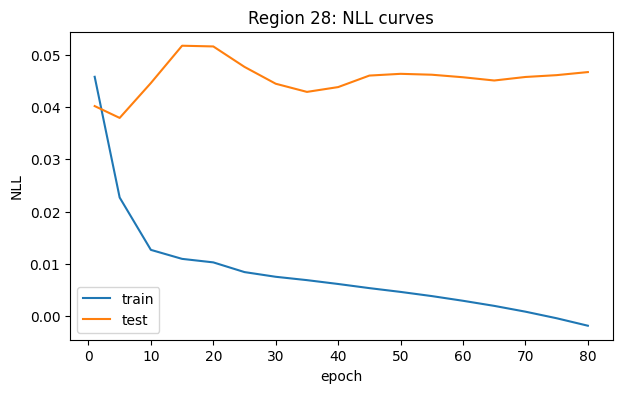

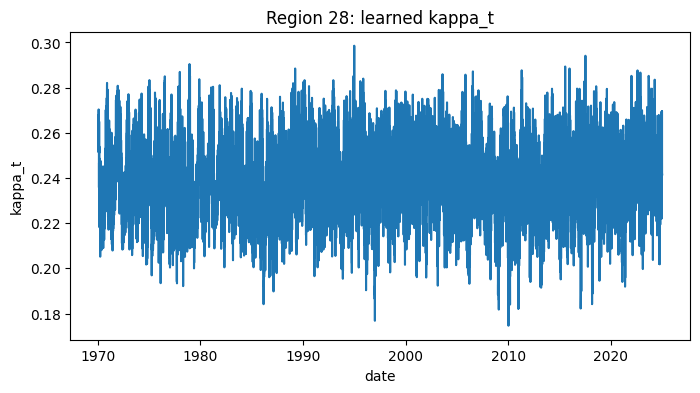

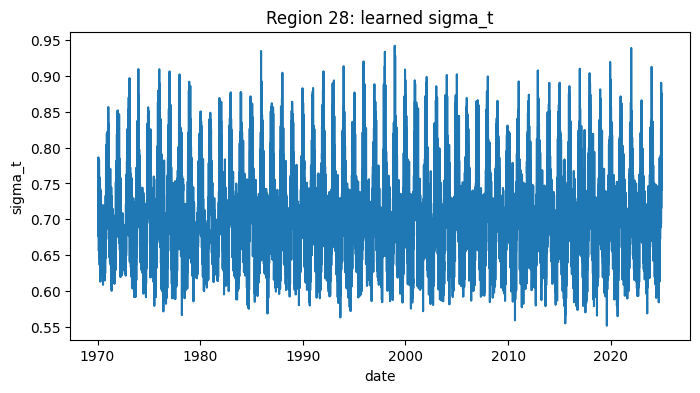

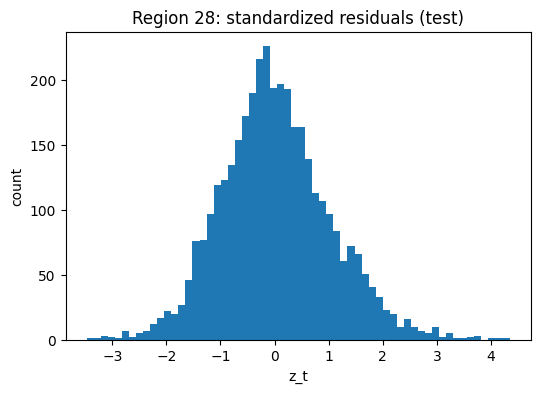

z mean: 0.0254716444760561 z std: 1.0102994441986084
saved model: ../Outputs/final_models/region_28_OU_FFNN_regionspecific.pt


In [28]:

# ============================================================
# FINAL MODEL DIAGNOSTIC PLOTS FOR ONE REGION
# ============================================================

REGION_TO_PLOT = GRID_REGIONS[3]

art = final_region_artifacts[REGION_TO_PLOT]
dfr = art["df"]
dates_k = dfr.loc[art["idx_t"], "date"].values

plt.figure(figsize=(7,4))
plt.plot(art["epochs_logged"], art["train_curve"], label="train")
plt.plot(art["epochs_logged"], art["test_curve"], label="test")
plt.title(f"Region {REGION_TO_PLOT}: NLL curves")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(dates_k, art["kappa_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned kappa_t")
plt.xlabel("date")
plt.ylabel("kappa_t")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(dates_k, art["sigma_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned sigma_t")
plt.xlabel("date")
plt.ylabel("sigma_t")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(art["z_test"], bins=60)
plt.title(f"Region {REGION_TO_PLOT}: standardized residuals (test)")
plt.xlabel("z_t")
plt.ylabel("count")
plt.show()

print("z mean:", float(np.mean(art["z_test"])), "z std:", float(np.std(art["z_test"])))
print("saved model:", art["save_path"])


In [23]:

# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

final_summary[[
    "region", "hidden", "activation", "n_layers",
    "test_nll", "mae", "rmse", "r2", "corr",
    "picp_90", "coverage_error_90", "z_mean", "z_std", "z_skew", "z_kurtosis"
]]


,region,hidden,activation,n_layers,test_nll,mae,rmse,r2,corr,picp_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis
0,11,128,relu,1,-0.004163,1.604414,2.012596,0.609046,0.780571,0.900602,0.000602,0.023999,0.994446,0.139865,3.127455
1,24,128,relu,1,-0.021874,1.607226,2.004585,0.617718,0.786041,0.914841,0.014841,0.018325,0.978480,0.116788,3.034784
2,27,32,relu,1,-0.039940,1.536205,1.941641,0.651302,0.809010,0.931252,0.031252,0.022836,0.894241,0.018523,3.330839
3,28,128,tanh,2,0.037934,1.291000,1.657096,0.615539,0.784693,0.903341,0.003341,0.025472,1.010299,0.313437,3.528444
4,32,64,tanh,2,-0.050907,1.422428,1.809605,0.622309,0.789046,0.907174,0.007174,0.013629,0.977379,0.302616,3.331523
5,44,128,leakyrelu,1,-0.123065,1.448460,1.840771,0.678336,0.823805,0.913746,0.013746,0.026676,0.963683,0.056307,3.321530
6,52,128,leakyrelu,2,-0.016842,1.471248,1.855007,0.605563,0.778343,0.914567,0.014567,0.022235,0.960309,0.169080,3.189900
7,53,64,leakyrelu,1,-0.015979,1.200822,1.530123,0.596551,0.772612,0.908543,0.008543,-0.003113,0.993942,0.260305,3.511295


# Final model architecture

In [24]:
# ============================================================
# FINAL MODEL TRAINING SETUP
# Region-specific final model selection
#   USE_GLOBAL_ARCH = False  -> each region uses its own best architecture
#   USE_GLOBAL_ARCH = True   -> force one shared architecture across all regions
# ============================================================

USE_GLOBAL_ARCH = False

# If using one global architecture for all regions:
FINAL_HIDDEN = 32
FINAL_ACTIVATION = "leakyrelu"
FINAL_N_LAYERS = 1

# Training hyperparameters
FINAL_EPOCHS = 2000
EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
EVAL_EVERY = 25
FINAL_LR = 1e-3
FINAL_KAPPA_MAX = 0.5
FINAL_WEIGHT_DECAY = 1e-4
FINAL_GRAD_CLIP = 1.0

# Fixed split
train_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")

FINAL_MODEL_DIR = "final_models_per_region"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)




In [25]:

# ============================================================
# EXPORT OU-NN TEMPERATURE MODELS TO PKL
# Model A only
# ============================================================

import pickle
from pathlib import Path

CALIB_END = "2014-12-31"
OUT_DIR = Path("../Outputs/OUNNParametersRegionSpecificModels/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "NN-OU Temperature Model (Region-Specific Architecture)"

def export_ou_nn_models_to_pkls(
    regions_to_export,
    final_models,
    final_region_artifacts,
    calib_end=CALIB_END,
    out_dir=OUT_DIR,
    save_combined=True,
):
    region_models = {}

    for reg in regions_to_export:
        if reg not in final_models or reg not in final_region_artifacts:
            print(f"Skipping region {reg}: model/artifact not found")
            continue

        art = final_region_artifacts[reg]
        model = final_models[reg]
        arch = art["arch"]

        model_dict = {
            "model_name": MODEL_NAME,
            "region_code": int(reg),
            "calib_end": str(calib_end),
            "nn_architecture": {
                "hidden": int(arch["hidden"]),
                "activation": str(arch["activation"]),
                "n_layers": int(arch["n_layers"]),
                "kappa_max": float(FINAL_KAPPA_MAX),
            },
            "nn_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
            "x_mean": float(art["x_mean"]),
            "x_std": float(art["x_std"]),
            "window": int(WINDOW),
            "doy_harmonics": int(DOY_HARMONICS),
            "seasonality_beta": art["beta"],
            "diagnostics": {
                "test_nll": float(art["metrics"]["test_nll"]),
                "mae": float(art["metrics"]["mae"]),
                "rmse": float(art["metrics"]["rmse"]),
                "r2": float(art["metrics"]["r2"]),
                "corr": float(art["metrics"]["corr"]),
                "picp_90": float(art["metrics"]["picp_90"]),
                "coverage_error_90": float(art["metrics"]["coverage_error_90"]),
                "z_mean": float(art["metrics"]["z_mean"]),
                "z_std": float(art["metrics"]["z_std"]),
                "z_skew": float(art["metrics"]["z_skew"]),
                "z_kurtosis": float(art["metrics"]["z_kurtosis"]),
            },
            "n_obs_train": int(np.sum(art["train_mask"])),
            "n_obs_test": int(np.sum(art["test_mask"])),
        }

        fname = out_dir / f"ou_nn_region_{int(reg):02d}_calib_end_{calib_end}.pkl"
        with open(fname, "wb") as f:
            pickle.dump(model_dict, f)
        print(f"Saved -> {fname}")

        region_models[int(reg)] = model_dict

    if save_combined:
        combined = {
            "model_name": MODEL_NAME,
            "calib_end": str(calib_end),
            "regions": sorted(region_models.keys()),
            "models_by_region": region_models,
        }

        fname_all = out_dir / f"ou_nn_all_regions_calib_end_{calib_end}.pkl"
        with open(fname_all, "wb") as f:
            pickle.dump(combined, f)
        print(f"Saved -> {fname_all}")

    return region_models

ou_nn_models = export_ou_nn_models_to_pkls(
    regions_to_export=GRID_REGIONS,
    final_models=final_models,
    final_region_artifacts=final_region_artifacts,
)


Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_11_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_24_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_27_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_28_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_32_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_44_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_52_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_region_53_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUNNParametersRegionSpecificModels/ou_nn_all_regions_calib_end_2014-12-31.pkl
